In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools

from snn import Network, NodeGroup, EdgeGroup, NodePort, NodeList
from snn.model import IN, LIF, PSP

# Simulator backend in STACS
from snn.backend import SimSTACS

In [2]:
# We are using the subtractor network example for simulation
class Input(Network):
    def __init__(self, spike_times, ctrl_times):
        super().__init__()
        self.spike_times = spike_times # n x t
        self.ctrl_times = ctrl_times   # 1 x t

    def build(self):
        self.spikegen = NodeGroup(IN(), len(self.spike_times), times=self.spike_times)
        self.ctrl_out = NodeGroup(IN(), 1, times=self.ctrl_times)

        return

class Adder(Network):
    def __init__(self):
        super().__init__()
        self.input = NodePort() # number of inputs generates a dependency
        self.ctrl_in = NodePort(1)

    def build(self):
        num_input = len(self.input)
        num_carry = 2 * num_input - 1
        self.carry = NodeGroup(LIF(), num_carry, threshold=[0.9+i for i in range(num_carry)])
        self.output = NodeGroup(LIF(threshold=0.9), 1) # default params can go in node model

        # Input to Carry
        self.ic = EdgeGroup(self.input, self.carry, PSP(),
                            list(itertools.product(range(num_input), range(num_carry))))

        # Carry to Carry
        edges = list()
        i = 1
        for c1 in range(1,num_carry,2):
            for c2 in range(c1-i,num_carry):
                edges.append((c1,c2))
            i += 1
        self.cc = EdgeGroup(self.carry, self.carry, PSP(), edges)

        # Carry to Output
        self.co = EdgeGroup(self.carry, self.output, PSP(),
                            edges=[(i,0) for i in range(num_carry)],
                            weight=[1.0 - (i%2)*2.0 for i in range(num_carry)])

        return

class Subtractor(Network):
    def __init__(self, len_inputs=4):
        super().__init__()
        self.len_inputs = len_inputs
        # input ports
        self.input = NodePort(2)
        self.ctrl_in = NodePort(1)

    def build(self):
        # Input helper node lists
        self.a = NodeList([self.input[0]])
        self.b = NodeList([self.input[1]])
        
        # Inversion
        # single neuron instantiation (default node size is 1)
        self.not_b = NodeGroup(LIF(threshold=0.9))
        # single synapse connection (default edge is (0, 0))
        self.b__nb = EdgeGroup(self.b, self.not_b, PSP(), weight=-1.0, delay=2.0)
        
        # Control relay (based on length of inputs)
        self.ctrl_relay = NodeGroup(LIF(), self.len_inputs, threshold=0.9)
        self.ci__r = EdgeGroup(self.ctrl_in, self.ctrl_relay, PSP(),
                               edges=[(0, i) for i in range(self.len_inputs)])
        self.cr__nb = EdgeGroup(self.ctrl_relay, self.not_b, PSP(),
                                edges=[(i, 0) for i in range(self.len_inputs)],
                                delay=[1.0 + i for i in range(self.len_inputs)])
        
        # Add 1 relay (to get the timing right)
        self.one_relay = NodeGroup(LIF(threshold=0.9))
        self.ci__or = EdgeGroup(self.ctrl_in, self.one_relay, PSP(), delay=2.0)
        
        # First Adder to get -B
        self.adder_b_input = NodeList([self.not_b[0], self.one_relay[0]])
        self.adder_b = Adder()
        self.connect(self.adder_b_input, self.adder_b.input)

        # A input relay (to get the timing right)
        self.a_relay = NodeGroup(LIF(), 1, threshold=0.9)
        self.a__ar = EdgeGroup(self.a, self.a_relay, PSP(), delay=4.0)

        # Second Adder for A - B
        self.adder_ab_input = NodeList([self.a_relay[0], self.adder_b.output[0]])
        self.adder_ab = Adder()
        self.connect(self.adder_ab_input, self.adder_ab.input)

        # Output
        self.output = NodeGroup(LIF(threshold=0.9), 1)
        self.ab__o = EdgeGroup(self.adder_ab.output, self.output, PSP())

        # Supress final carry out (not sure if this is needed)
        self.ci__o = EdgeGroup(self.ctrl_in, self.output, PSP(),
                               weight=-1, delay=self.len_inputs + 7.0)

        # Output start timing (for downstream)
        self.ctrl_out = NodeGroup(LIF(threshold=0.9))
        self.ci__co = EdgeGroup(self.ctrl_in, self.ctrl_out, PSP(), delay=7.0)

        return

In [3]:
# Set up the network and build it
input_vec = [[0, 3, 5], # 1,0,1,0,0,1
             [1, 2, 4]] # 0,1,0,1,1,0
ctrl_vec  = [[0]]

net = Network()
net.i = Input(spike_times=input_vec, ctrl_times=ctrl_vec)
net.s = Subtractor(len_inputs=6)
net.connect(net.i.spikegen, net.s.input)
net.connect(net.i.ctrl_out, net.s.ctrl_in)
net.build()

info: adding network i
info: adding network s
info: building network i
info: building network s
info: adding network s.adder_b
info: adding network s.adder_ab
info: linking port s.adder_b.input
info: linking port s.adder_ab.input
info: resolving dependency for s.adder_b.input
info: resolving dependency for s.adder_ab.input
info: building network s.adder_b
info: building network s.adder_ab
info: linking port s.input
info: linking port s.ctrl_in
info: flattening network topology


In [4]:
# Pass the built network to the STACS simulator
sim = SimSTACS(net)

# This converts the SNN-DSL network topology
# to a SNN-dCSR network snapshot directory
sim.compile(netparts=2, prefix='./dslnet')

# Run the STACS simulator for a number of timesteps
sim.run(20, verbose=True)

/Users/felwang/Documents/Projects/STACS/stacs/charmrun +p2 /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml

Running as 2 OS processes:  /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml 
charmrun> mpirun -np 2  /Users/felwang/Documents/Projects/STACS/stacs/stacs ./dslnet/network.yml 
Charm++> Running on MPI version: 4.1
Charm++> level of thread support used: -1 (desired: 0)
Charm++> Running in non-SMP mode: 2 processes (PEs)
Converse/Charm++ Commit ID: v70000
Charm++ built without optimization.
Do not use for performance benchmarking (build with --with-production to do so).
Charm++ built with internal error checking enabled.
Do not use for performance benchmarking (build without --enable-error-checking to do so).
Isomalloc> Synchronized global address space.
CharmLB> Load balancer assumes all CPUs are same.
Charm++> Running on 1 hosts (1 sockets x 12 cores x 1 PUs = 12-way SMP)
Charm++> cpu topology info is gathered in 0.004 seconds.

Sim

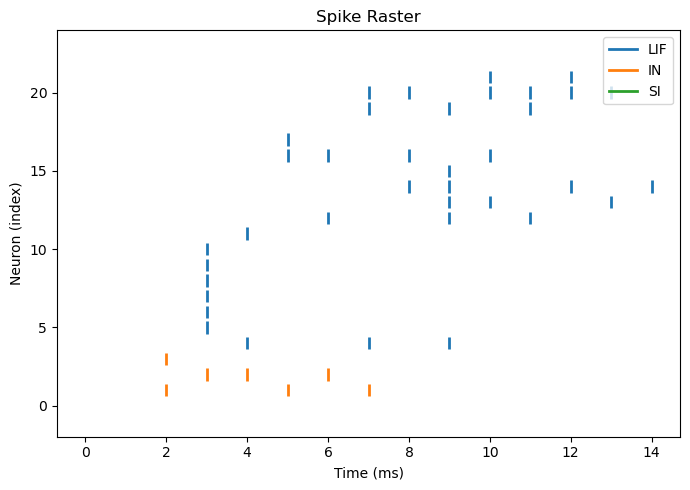

In [5]:
# We can also plot the spikes
sim.plot_spikes(figsize=(7,5), linewidths=2.0)

In [6]:
# The spike list is a list of times for each node
spike_list = sim.get_spikes()
for times in spike_list:
    print(times)

[]
[2.0, 5.0, 7.0]
[3.0, 4.0, 6.0]
[2.0]
[4.0, 7.0, 9.0]
[3.0]
[3.0]
[3.0]
[3.0]
[3.0]
[3.0]
[4.0]
[6.0, 9.0, 11.0]
[9.0, 10.0, 13.0]
[8.0, 9.0, 12.0, 14.0]
[9.0]
[5.0, 6.0, 8.0, 10.0]
[5.0]
[]
[7.0, 9.0, 11.0]
[7.0, 8.0, 10.0, 11.0, 12.0, 13.0]
[10.0, 12.0]
[]


In [7]:
# We can extract specific output nodes (by name)
index_output = sim.node_map[net.s.output[0].name] # output node for our computation
index_ctrl_out = sim.node_map['s.ctrl_out[0]'] # node indicating when the output starts

# Get the relevant spike times
output_spike = spike_list[index_output]
output_start = spike_list[index_ctrl_out]
print(f"output_spike = {output_spike}")
print(f"output_start = {output_start}")

# We can convert this into a dense bit string
bit_string = [0 for _ in range(6)]
t0 = output_start[0]
for t in spike_list[index_output]:
    timestep = int(t - t0)
    bit_string[timestep] = 1

# Expected output: 101001 - 010110 = 010011
# Output is ordered with least-significant bits first (in time)
print(f"output_bits  = {list(reversed(bit_string))}")

output_spike = [9.0, 10.0, 13.0]
output_start = [9.0]
output_bits  = [0, 1, 0, 0, 1, 1]
